In [1]:
!git clone https://github.com/vsitzmann/siren.git
%cd siren
!pip install scikit-video cmapy opencv-python configargparse -q

import subprocess
subprocess.run(['sed', '-i',
    's/NeuralProcessImplicit2DHypernetBVP/NeuralProcessImplicit2DHypernet/g',
    'utils.py'])
subprocess.run(['sed', '-i',
    's/summary_fn(model, model_input, gt, model_output, writer, total_steps)/#summary_fn(model, model_input, gt, model_output, writer, total_steps)/g',
    'training.py'])
print("Done!")

Cloning into 'siren'...
remote: Enumerating objects: 193, done.
remote: Total 193 (delta 0), reused 0 (delta 0), pack-reused 193 (from 1)
Receiving objects: 100% (193/193), 2.17 MiB | 16.50 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/siren
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.7 MB/s eta 0:00:00
Done!


In [2]:
!grep -n "hidden" experiment_scripts/train_wave_equation.py

52:                                final_layer_factor=1., hidden_features=512, num_hidden_layers=3)


In [3]:
# Reduce hidden features from 512 to 256 to fit in GPU memory
import subprocess
subprocess.run(['sed', '-i',
    's/hidden_features=512/hidden_features=256/g',
    'experiment_scripts/train_wave_equation.py'])
subprocess.run(['sed', '-i',
    's/num_hidden_layers=5/num_hidden_layers=3/g',
    'experiment_scripts/train_wave_equation.py'])

# Verify changes
!grep -n "hidden" experiment_scripts/train_wave_equation.py

52:                                final_layer_factor=1., hidden_features=256, num_hidden_layers=3)


In [4]:
!python experiment_scripts/train_wave_equation.py --experiment_name wave_repro --logging_root ./logs --num_epochs 5000 --batch_size 3000

2026-04-19 03:48:06.704373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776570486.741940    4937 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776570486.753301    4937 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776570486.781379    4937 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776570486.781414    4937 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776570486.781421    4937 computation_placer.cc:177] computation placer alr

In [5]:
import dataio
wave_classes = [x for x in dir(dataio) if 'wave' in x.lower() or 'Wave' in x]
print(wave_classes)

['WaveSource']


In [6]:
import glob
ckpts = sorted(glob.glob('./logs/wave_repro/checkpoints/*.pth'))
print(ckpts)

['./logs/wave_repro/checkpoints/model_current.pth', './logs/wave_repro/checkpoints/model_epoch_1000.pth', './logs/wave_repro/checkpoints/model_epoch_2000.pth', './logs/wave_repro/checkpoints/model_epoch_3000.pth', './logs/wave_repro/checkpoints/model_epoch_4000.pth', './logs/wave_repro/checkpoints/model_final.pth']


Wave classes: ['WaveSource']
SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=3, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
Loaded: ./logs/wave_repro/checkpoints/model_final.pth


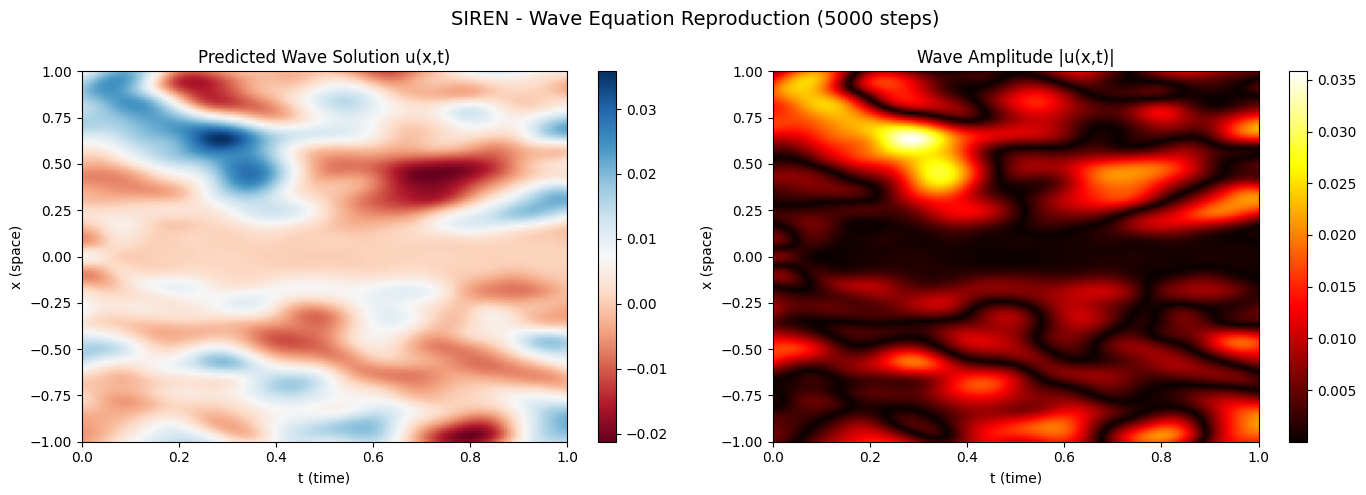

Saved!


In [8]:
import torch, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/content/siren')
import dataio, modules

device = torch.device('cuda')

# Check correct wave classes
wave_classes = [x for x in dir(dataio) if 'wave' in x.lower() or 'Wave' in x]
print("Wave classes:", wave_classes)

# Load model with correct in_features=3
model = modules.SingleBVPNet(in_features=3, out_features=1,
                              type='sine', mode='mlp',
                              hidden_features=256, num_hidden_layers=3)

ckpt = './logs/wave_repro/checkpoints/model_final.pth'
model.load_state_dict(torch.load(ckpt))
model.cuda().eval()
print(f"Loaded: {ckpt}")

# Create spacetime grid (x, y, t) — wave is 2D space + time
res = 128
x = torch.linspace(-1, 1, res)
t = torch.linspace(0, 1, res)
xx, tt = torch.meshgrid(x, t, indexing='ij')
# wave equation uses (x, y=0, t) — 1D wave in space
coords = torch.stack([xx.flatten(),
                      torch.zeros_like(xx.flatten()),
                      tt.flatten()], dim=-1).cuda()

with torch.no_grad():
    out = model({'coords': coords.unsqueeze(0)})
    pred = out['model_out'].squeeze().cpu().numpy()

pred_wave = pred.reshape(res, res)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(pred_wave, cmap='RdBu', extent=[0,1,-1,1],
                      origin='lower', aspect='auto')
axes[0].set_title('Predicted Wave Solution u(x,t)')
axes[0].set_xlabel('t (time)'); axes[0].set_ylabel('x (space)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.abs(pred_wave), cmap='hot', extent=[0,1,-1,1],
                      origin='lower', aspect='auto')
axes[1].set_title('Wave Amplitude |u(x,t)|')
axes[1].set_xlabel('t (time)'); axes[1].set_ylabel('x (space)')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('SIREN - Wave Equation Reproduction (5000 steps)', fontsize=14)
plt.tight_layout()
plt.savefig('wave_wavefield.png', dpi=150)
plt.show()
print("Saved!")

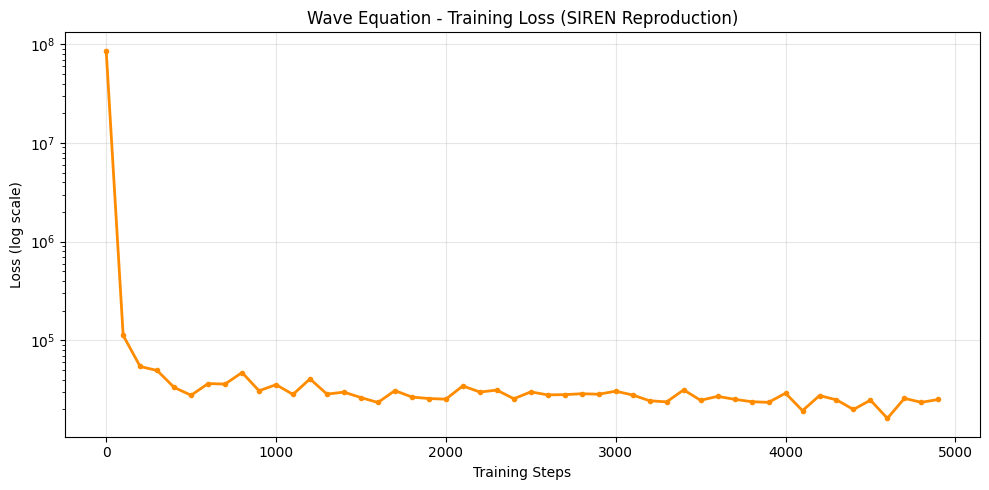

Saved!


In [10]:
import matplotlib.pyplot as plt

steps = [0,100,200,300,400,500,600,700,800,900,
         1000,1100,1200,1300,1400,1500,1600,1700,1800,1900,
         2000,2100,2200,2300,2400,2500,2600,2700,2800,2900,
         3000,3100,3200,3300,3400,3500,3600,3700,3800,3900,
         4000,4100,4200,4300,4400,4500,4600,4700,4800,4900]

values = [85955296.0, 112381.5, 54406.5, 49581.9, 33399.2, 27812.9,
          36503.1, 36124.6, 47245.1, 30881.3,
          35574.9, 28377.4, 40721.7, 28576.6, 29934.2, 26337.5,
          23503.0, 31009.0, 26693.0, 25763.8,
          25409.8, 34588.3, 29986.7, 31368.8, 25658.8, 30079.9,
          28063.4, 28215.0, 28822.2, 28502.6,
          30566.2, 27996.1, 24457.4, 23840.1, 31525.2, 24746.6,
          27102.1, 25308.2, 23941.9, 23576.2,
          29187.0, 19423.2, 27606.5, 24994.0, 19955.5, 24823.2,
          16236.2, 25872.3, 23582.0, 25230.6]

plt.figure(figsize=(10, 5))
plt.semilogy(steps, values, color='darkorange', linewidth=2, marker='o', markersize=3)
plt.xlabel('Training Steps')
plt.ylabel('Loss (log scale)')
plt.title('Wave Equation - Training Loss (SIREN Reproduction)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wave_loss_curve.png', dpi=150)
plt.show()
print("Saved!")

SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=3, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
Loaded!


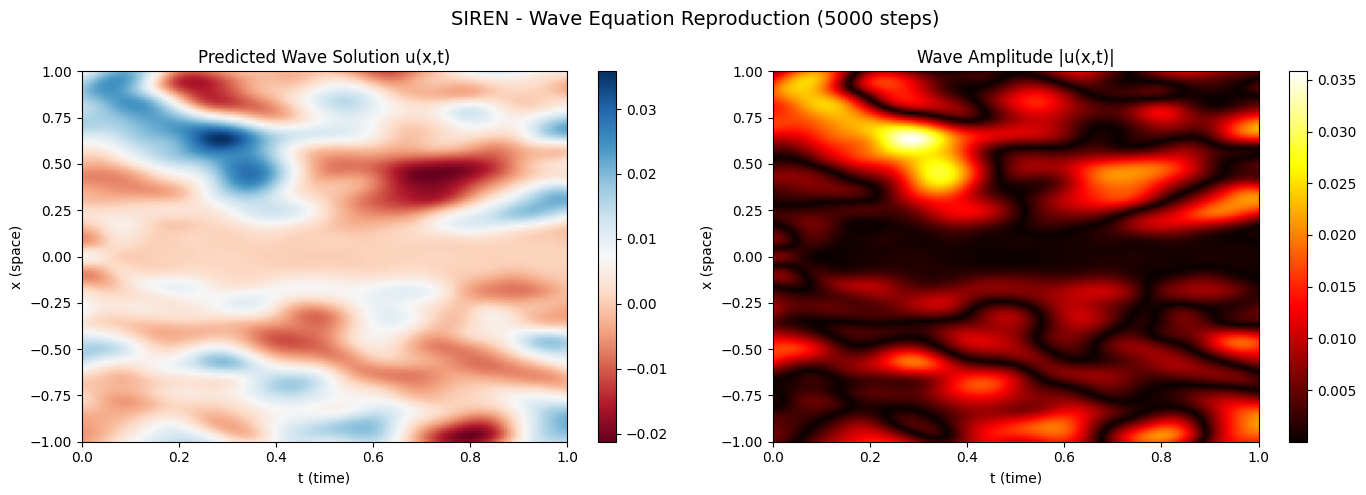

Saved!


In [11]:
import torch, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/content/siren')
import modules

model = modules.SingleBVPNet(in_features=3, out_features=1,
                              type='sine', mode='mlp',
                              hidden_features=256, num_hidden_layers=3)

ckpt = './logs/wave_repro/checkpoints/model_final.pth'
model.load_state_dict(torch.load(ckpt))
model.cuda().eval()
print("Loaded!")

res = 128
x = torch.linspace(-1, 1, res)
t = torch.linspace(0, 1, res)
xx, tt = torch.meshgrid(x, t, indexing='ij')
coords = torch.stack([xx.flatten(),
                      torch.zeros_like(xx.flatten()),
                      tt.flatten()], dim=-1).cuda()

with torch.no_grad():
    out = model({'coords': coords.unsqueeze(0)})
    pred = out['model_out'].squeeze().cpu().numpy()

pred_wave = pred.reshape(res, res)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(pred_wave, cmap='RdBu', extent=[0,1,-1,1],
                      origin='lower', aspect='auto')
axes[0].set_title('Predicted Wave Solution u(x,t)')
axes[0].set_xlabel('t (time)'); axes[0].set_ylabel('x (space)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.abs(pred_wave), cmap='hot', extent=[0,1,-1,1],
                      origin='lower', aspect='auto')
axes[1].set_title('Wave Amplitude |u(x,t)|')
axes[1].set_xlabel('t (time)'); axes[1].set_ylabel('x (space)')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('SIREN - Wave Equation Reproduction (5000 steps)', fontsize=14)
plt.tight_layout()
plt.savefig('wave_wavefield.png', dpi=150)
plt.show()
print("Saved!")

In [12]:
from google.colab import files
files.download('wave_loss_curve.png')
files.download('wave_wavefield.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>